# 🌍 TabPFN-3.5 Land-Cover Training at the Polygon Level (Ghana)

Trains a **TabPFN-3.5** classifier ([Prior Labs](https://priorlabs.ai/)) to map Ghanaian land cover from
**Google Satellite Embedding** vectors (64-dimensional, bands `A00`-`A63`), benchmarks it against four
standard classifiers under an identical protocol, measures the calibration of its probabilities, and
exports the deployable model.

## Training data

`Training_Samples.csv` holds 440,208 pixels sampled from **318 single-class field polygons** covering 23
land-cover classes. The polygons were digitized in Google Earth Pro, and the embedding values of every pixel
inside them were extracted in Google Earth Engine from
[`GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL`](https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_SATELLITE_EMBEDDING_V1_ANNUAL)
(year 2025). The parent polygon of each pixel is encoded in `system:index`. Several classes occur only in
particular regions of the country - mangroves and salt pans, for example, are coastal - so their polygons
are geographically concentrated.

## Method

1. **One row per polygon.** Pixels of the same polygon are near-duplicate observations, so each polygon is
   collapsed to its mean embedding and its single class code. The polygon is the unit of replication
   throughout.
2. **Leave-One-Polygon-Out cross-validation (LOO).** Each of the 318 polygons is held out once while the model
   is fit on the other 317. TabPFN-3.5 learns in context in about a second per fit, so the full 318-fold
   evaluation takes minutes and every polygon of every class receives an out-of-sample prediction.
3. **Raw-pixel scoring.** Each fold also classifies every raw pixel of the held-out polygon, measuring
   accuracy on the individual pixels that wall-to-wall inference classifies.
4. **Per-class Wilson 95% confidence intervals** express the uncertainty of classes with few polygons.
5. **Baselines under the identical protocol.** Random Forest, XGBoost, logistic regression and k-nearest
   neighbours are evaluated by the same LOO runner (`lc_eval.run_loo`): same folds, same training rows, same
   raw-pixel scoring. No model is hyperparameter-tuned.
6. **Calibration.** Reliability diagrams and expected calibration error (ECE) at polygon and pixel level test
   whether the top-class probability can be read as the probability that a prediction is correct - the
   property behind the confidence map of `Predict_TabPFN35_PolygonLevel.ipynb`.
7. **Export.** The polygon-mean table (the model's complete training context, used by `quickstart.py`) and
   the TabPFN-3.5 model fit on all 318 polygons.

## Outputs

`data/polygon_means.csv` - the 318 polygon-mean embeddings with class, pixel count and centroid.

All other files are written to `outputs_tabpfn35_polygon/`:

| File | Contents |
|---|---|
| `loo_predictions.csv` | TabPFN-3.5 LOO predictions, one row per polygon (class, confidence, raw-pixel tallies). |
| `polygon_metrics_summary.json` | TabPFN-3.5 metrics (23- and 17-class), class mapping, baseline summary. |
| `polygon_classification_report.csv` | Per-class precision / recall / F1. |
| `polygon_confusion_matrix.png` | LOO confusion matrix. |
| `polygon_class_summary.csv` | Per-class polygon counts, LOO accuracy with Wilson 95% CIs, raw-pixel accuracy. |
| `held_out_pixel_composition.csv` | Share of all held-out pixels and raw-pixel accuracy per class. |
| `model_comparison.csv` / `model_comparison.png` | TabPFN-3.5 vs. baselines under identical LOO. |
| `loo_probabilities.npz` | Out-of-sample probabilities and pixel-level predictions of every model. |
| `reliability_diagram.png` | Reliability diagrams at polygon and pixel level for every model. |
| `calibration_bins.csv` / `calibration_summary.json` | Reliability bins, ECE, accuracy above / below the low-confidence threshold. |
| `tabpfn35_polygon_model.joblib` | Final TabPFN-3.5 model fit on all 318 polygons. |

In [1]:
# ==========================================
# 0. API Token Setup
# ==========================================
# A Prior Labs API token is required: copy .env.example to .env and set
# TABPFN_TOKEN=<your key> (keys are issued at https://ux.priorlabs.ai/account).
import os
from dotenv import load_dotenv

load_dotenv(dotenv_path=os.path.join(os.getcwd(), '.env'))

token = os.getenv('TABPFN_TOKEN')
if not token:
    raise ValueError(
        'TABPFN_TOKEN not found. '
        'Please create a .env file in the project folder with:\n'
        '  TABPFN_TOKEN=your-api-key-here\n'
        'Get your key at: https://ux.priorlabs.ai/account'
    )
os.environ['TABPFN_TOKEN'] = token
print('TabPFN token loaded successfully.')

TabPFN token loaded successfully.


In [2]:
# ==========================================
# 1. Configure Paths & Evaluation Settings
# ==========================================
import lc_eval

DATA_CSV_PATH = os.path.join(os.getcwd(), 'Training_Samples.csv')
RECLASS_XLSX_PATH = os.path.join(os.getcwd(), 'new_class.xlsx')
DATA_DIR = os.path.join(os.getcwd(), 'data')
POLYGON_MEANS_PATH = os.path.join(DATA_DIR, 'polygon_means.csv')
OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs_tabpfn35_polygon')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42

# Top-class probability below which a prediction counts as low confidence; the
# prediction notebook reports it on the confidence map (read from
# calibration_summary.json).
LOW_CONFIDENCE_THRESHOLD = 0.6
RELIABILITY_BINS = 10

print(f'Dataset path:     {DATA_CSV_PATH}')
print(f'Training context: {POLYGON_MEANS_PATH}')
print(f'Output directory: {OUTPUT_DIR}')

Dataset path:     /u/mayeh/Gh_LC/Training_Samples.csv
Training context: /u/mayeh/Gh_LC/data/polygon_means.csv
Output directory: /u/mayeh/Gh_LC/outputs_tabpfn35_polygon


In [3]:
# ==========================================
# 2. Load Pixels & Collapse to One Row per Polygon
# ==========================================
import numpy as np
import pandas as pd

assert os.path.exists(DATA_CSV_PATH), (
    f'CSV file not found at: {DATA_CSV_PATH}\n'
    'Download Training_Samples.csv from the data link in README.md and place it here.'
)

df = pd.read_csv(DATA_CSV_PATH)
print(f'Raw pixel rows loaded: {df.shape[0]:,}')

embedding_cols = [c for c in df.columns if c.startswith('A') and c[1:].isdigit()]
assert embedding_cols == lc_eval.EMBEDDING_COLS, 'Expected embedding columns A00..A63, in order.'
print(f'Embedding columns: {len(embedding_cols)} ({embedding_cols[0]}..{embedding_cols[-1]})')

# Earth Engine writes `system:index` as '<polygon_id>_<polygon_id>_<pixel_n>'
# (e.g. '00000000000000000122_00000000000000000122_7'); removing the trailing
# '_<pixel_n>' recovers the polygon each pixel was sampled from.
df['_polygon_id'] = df['system:index'].str.rsplit('_', n=1).str[0]
n_polygons = df['_polygon_id'].nunique()
print(f'Independent polygons recovered: {n_polygons}')

# Each polygon carries exactly one class code.
code_nunique_per_polygon = df.groupby('_polygon_id')['code'].nunique()
mixed_polygons = code_nunique_per_polygon[code_nunique_per_polygon > 1]
assert len(mixed_polygons) == 0, (
    f'{len(mixed_polygons)} polygon(s) contain more than one class code; '
    'every polygon must map to a single class.'
)
print('[✓] Every polygon maps to exactly one class code.')

# Pixel coordinates (Earth Engine `.geo` points) locate each polygon's centroid.
pixel_lonlat = lc_eval.parse_point_coordinates(df['.geo'])
assert pixel_lonlat.notna().all().all(), 'Some `.geo` entries could not be parsed as points.'
df['_lon'] = pixel_lonlat['lon'].to_numpy()
df['_lat'] = pixel_lonlat['lat'].to_numpy()

# One row per polygon: mean embedding, class code and name, pixel count, centroid.
by_polygon = df.groupby('_polygon_id')
poly_df = by_polygon[embedding_cols].mean()
poly_df['code'] = by_polygon['code'].first().astype(int)
poly_df['Name'] = by_polygon['Name'].first()
poly_df['n_pixels'] = by_polygon.size()
poly_df['centroid_lon'] = by_polygon['_lon'].mean()
poly_df['centroid_lat'] = by_polygon['_lat'].mean()
poly_df = poly_df.reset_index().rename(columns={'_polygon_id': 'polygon_id'})

print(f'\nCollapsed dataset: {poly_df.shape[0]} rows (one per polygon), {len(embedding_cols)} features.')
print('\nPolygons per class:')
print(poly_df.groupby(['code', 'Name']).size().sort_values().to_string())

# The model is fit on polygon means and applied to individual pixels; each
# polygon's raw pixels are kept for the raw-pixel scoring of every LOO fold.
raw_pixels_by_polygon = {
    pid: g[embedding_cols].reset_index(drop=True) for pid, g in by_polygon
}

# The 318-row table is the model's complete training context (used by quickstart.py).
polygon_means_cols = ['polygon_id', 'code', 'Name', 'n_pixels', 'centroid_lon', 'centroid_lat'] + embedding_cols
poly_df[polygon_means_cols].to_csv(POLYGON_MEANS_PATH, index=False)
print(f'\nSaved training context: {POLYGON_MEANS_PATH} '
      f'({os.path.getsize(POLYGON_MEANS_PATH) / 1024:.0f} KB)')

Raw pixel rows loaded: 440,208
Embedding columns: 64 (A00..A63)
Independent polygons recovered: 318
[✓] Every polygon maps to exactly one class code.

Collapsed dataset: 318 rows (one per polygon), 64 features.

Polygons per class:
code  Name              
6     Salt                   3
11    P_flood                3
15    Mining                 5
7     S_Flood                5
19    Beach                  5
20    Bare_Rocks             6
3     Woodland_Savanna       7
12    Open_Savannah          7
8     Rubber                 7
17    Closed_Forest          8
9     Rice                   9
4     Water                  9
16    Mango                 11
10    Palm                  12
21    ANN                   13
13    Open_Low_Shrubland    14
18    built-up              15
5     Shrub_Crop            15
14    Open_Forest           17
23    cashew                20
1     wetland               29
2     mangrove20            49
22    cocoa                 49

Saved training context: /u/ma

In [4]:
# ==========================================
# 3. Class Mapping, Feature/Label Arrays & Final Legend
# ==========================================
code_to_name = poly_df.drop_duplicates(subset=['code']).set_index('code')['Name'].to_dict()
classes = np.array(sorted(code_to_name))
print('Class code -> class name mapping:')
for c in classes:
    print(f'  Code {c:2d} -> {code_to_name[c]}')

X_poly = poly_df[embedding_cols].reset_index(drop=True)
y_poly = poly_df['code'].reset_index(drop=True)
polygon_ids = poly_df['polygon_id'].reset_index(drop=True)
n_pixels_per_poly = poly_df['n_pixels'].reset_index(drop=True)

print(f'\nX_poly shape: {X_poly.shape}   y_poly shape: {y_poly.shape}')
print(f'Pixels-per-polygon distribution:\n{n_pixels_per_poly.describe()}')

# The final map merges the 23 field classes into a 17-class legend
# (new_class.xlsx); metrics are reported at both levels.
reclass_lut, reclass_df = lc_eval.load_reclass_lut(RECLASS_XLSX_PATH)
unmapped = [int(c) for c in classes if reclass_lut[c] == 0]
assert not unmapped, f'Class codes missing from new_class.xlsx: {unmapped}'
final_code_to_name = dict(zip(reclass_df['New Class Code'].astype(int), reclass_df['New Class']))
print(f'\nFinal legend: {len(final_code_to_name)} classes (new_class.xlsx).')

Class code -> class name mapping:
  Code  1 -> wetland
  Code  2 -> mangrove20
  Code  3 -> Woodland_Savanna
  Code  4 -> Water
  Code  5 -> Shrub_Crop
  Code  6 -> Salt
  Code  7 -> S_Flood
  Code  8 -> Rubber
  Code  9 -> Rice
  Code 10 -> Palm
  Code 11 -> P_flood
  Code 12 -> Open_Savannah
  Code 13 -> Open_Low_Shrubland
  Code 14 -> Open_Forest
  Code 15 -> Mining
  Code 16 -> Mango
  Code 17 -> Closed_Forest
  Code 18 -> built-up
  Code 19 -> Beach
  Code 20 -> Bare_Rocks
  Code 21 -> ANN
  Code 22 -> cocoa
  Code 23 -> cashew

X_poly shape: (318, 64)   y_poly shape: (318,)
Pixels-per-polygon distribution:
count      318.000000
mean      1384.301887
std       6244.134889
min          1.000000
25%         46.500000
50%        266.500000
75%        831.500000
max      92449.000000
Name: n_pixels, dtype: float64

Final legend: 17 classes (new_class.xlsx).


In [5]:
# ==========================================
# 4. Initialize TabPFN-3.5
# ==========================================
import torch
from tabpfn import TabPFNClassifier
from tabpfn.constants import ModelVersion

# TabPFN-3.5 ships in tabpfn 9.0.0 and later.
assert hasattr(ModelVersion, 'V3_5'), (
    'This notebook requires TabPFN-3.5, which is not available in your installed '
    'tabpfn package. Upgrade with: pip install -U "tabpfn>=9.0.0"'
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using compute device: {device}')

# create_default_for_version selects the standard TabPFN-3.5 checkpoint with its
# recommended default settings. The in-context training set holds at most 318
# rows, well within TabPFN-3.5's capacity.
tabpfn35_classifier = TabPFNClassifier.create_default_for_version(
    ModelVersion.V3_5,
    device=device,
    random_state=RANDOM_STATE,
    show_progress_bar=False,
)
print('TabPFN-3.5 classifier initialized (standard checkpoint).')

Using compute device: cuda
TabPFN-3.5 classifier initialized (standard checkpoint).


In [6]:
# ==========================================
# 5. Leave-One-Polygon-Out Cross-Validation (TabPFN-3.5)
# ==========================================
# lc_eval.run_loo holds out each polygon once, fits on the remaining 317 polygon
# means, and scores the held-out polygon on its mean embedding and on each of
# its raw pixels. Every fit() replaces the in-context training set, so a single
# classifier instance serves all folds.
tabpfn_loo = lc_eval.run_loo(
    make_model=lambda: tabpfn35_classifier,
    X=X_poly,
    y=y_poly,
    polygon_ids=polygon_ids,
    raw_pixels_by_polygon=raw_pixels_by_polygon,
    classes=classes,
    model_name='TabPFN-3.5',
    code_to_name=code_to_name,
)
results_df = tabpfn_loo.records

loo_csv_path = os.path.join(OUTPUT_DIR, 'loo_predictions.csv')
results_df.to_csv(loo_csv_path, index=False)
print(f'Saved per-polygon LOO predictions: {loo_csv_path}')

[TabPFN-3.5] Leave-One-Polygon-Out across 318 polygons...
  [TabPFN-3.5] fold 25/318 | 0.8 min elapsed | ~9.7 min remaining
  [TabPFN-3.5] fold 50/318 | 1.6 min elapsed | ~8.4 min remaining
  [TabPFN-3.5] fold 75/318 | 2.3 min elapsed | ~7.5 min remaining
  [TabPFN-3.5] fold 100/318 | 3.1 min elapsed | ~6.9 min remaining
  [TabPFN-3.5] fold 125/318 | 4.0 min elapsed | ~6.1 min remaining
  [TabPFN-3.5] fold 150/318 | 4.8 min elapsed | ~5.4 min remaining
  [TabPFN-3.5] fold 175/318 | 5.8 min elapsed | ~4.7 min remaining
  [TabPFN-3.5] fold 200/318 | 6.6 min elapsed | ~3.9 min remaining
  [TabPFN-3.5] fold 225/318 | 7.6 min elapsed | ~3.1 min remaining
  [TabPFN-3.5] fold 250/318 | 8.6 min elapsed | ~2.3 min remaining
  [TabPFN-3.5] fold 275/318 | 9.5 min elapsed | ~1.5 min remaining
  [TabPFN-3.5] fold 300/318 | 10.5 min elapsed | ~0.6 min remaining
  [TabPFN-3.5] fold 318/318 | 11.4 min elapsed | ~0.0 min remaining
[✓] [TabPFN-3.5] LOO completed in 11.4 min (2.15 s/fold).
Saved per-poly

   TABPFN-3.5 LEAVE-ONE-POLYGON-OUT EVALUATION (n=318 polygons)
  Overall accuracy (polygon mean)                             83.33%
  Balanced accuracy (polygon mean)                            80.71%
  Macro F1                                                    80.93%
  Macro precision                                             81.75%
  Macro recall                                                80.71%
  Top-3 accuracy (polygon mean)                               97.48%
  Raw-pixel accuracy, micro (every pixel equal)               87.16%
  Raw-pixel accuracy, macro (every polygon equal)             81.59%
  Raw-pixel accuracy, class-balanced (every class equal)      81.46%
  17-class accuracy (polygon mean)                            84.28%
  17-class balanced accuracy (polygon mean)                   80.32%
  17-class raw-pixel accuracy, micro                          87.77%
  17-class raw-pixel accuracy, macro                          82.69%
Polygon-mean metrics score one mean-emb

,code,name,held_out_pixels,correct_pixels,share_of_held_out_pixels,raw_pixel_accuracy
0,4,Water,147838,146782,0.335837,0.992857
1,1,wetland,83456,72669,0.189583,0.870746
2,2,mangrove20,35687,33954,0.081068,0.951439
3,9,Rice,24796,21141,0.056328,0.852597
4,15,Mining,23237,21279,0.052786,0.915738
5,12,Open_Savannah,20850,12608,0.047364,0.604700
6,6,Salt,18143,5313,0.041215,0.292840
7,13,Open_Low_Shrubland,10579,5929,0.024032,0.560450


Saved held-out pixel composition: /u/mayeh/Gh_LC/outputs_tabpfn35_polygon/held_out_pixel_composition.csv

Per-class classification report (polygon-mean predictions):
                        precision    recall  f1-score   support

            1: wetland       0.81      0.90      0.85        29
         2: mangrove20       0.92      0.92      0.92        49
   3: Woodland_Savanna       0.86      0.86      0.86         7
              4: Water       0.89      0.89      0.89         9
         5: Shrub_Crop       0.62      0.53      0.57        15
               6: Salt       0.67      0.67      0.67         3
            7: S_Flood       0.80      0.80      0.80         5
             8: Rubber       1.00      1.00      1.00         7
               9: Rice       0.50      0.33      0.40         9
              10: Palm       1.00      1.00      1.00        12
           11: P_flood       1.00      1.00      1.00         3
     12: Open_Savannah       0.83      0.71      0.77         7
1

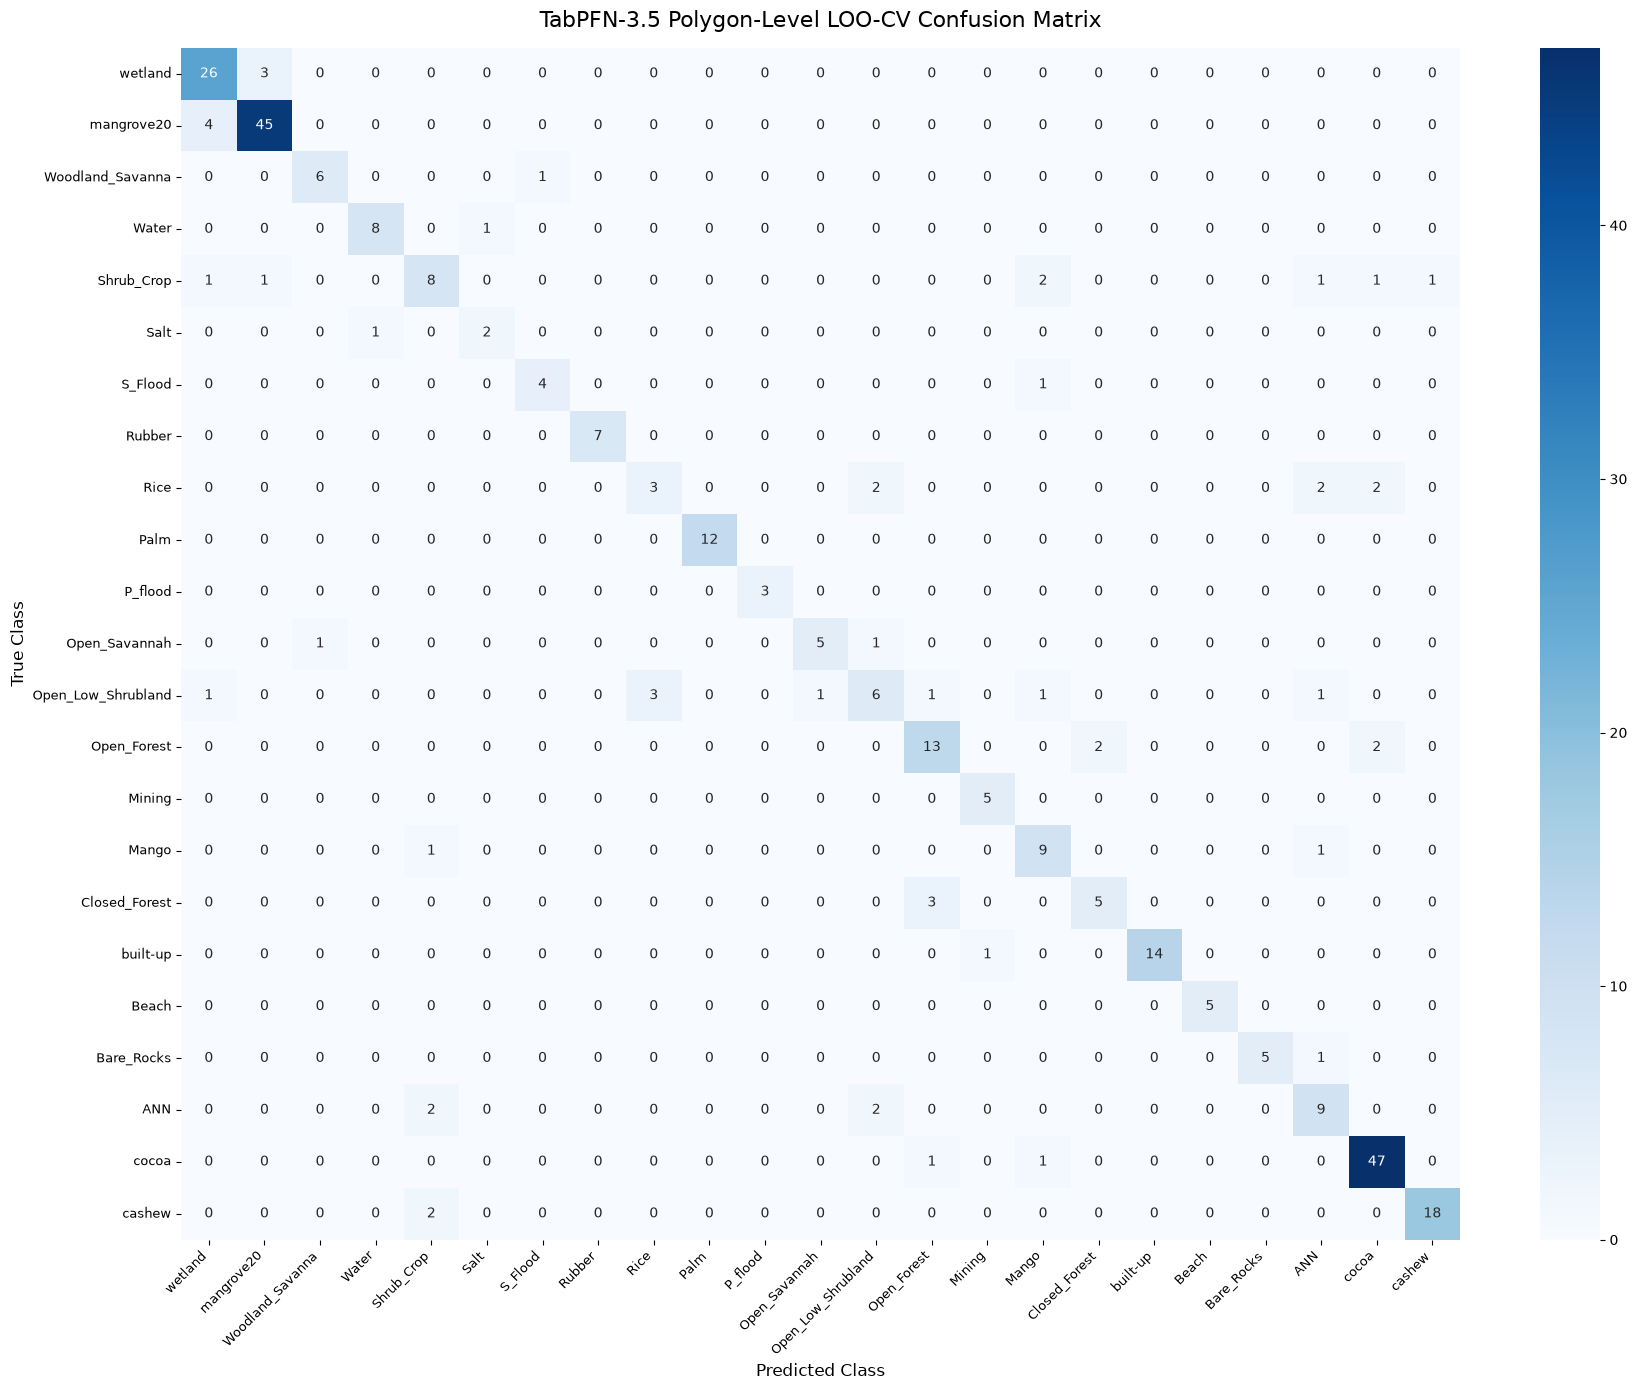

Classification report saved to: /u/mayeh/Gh_LC/outputs_tabpfn35_polygon/polygon_classification_report.csv


In [7]:
# ==========================================
# 6. TabPFN-3.5 Metrics
# ==========================================
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

tabpfn_summary = lc_eval.summarize_loo(tabpfn_loo, reclass_lut, n_bins=RELIABILITY_BINS)

metric_rows = [
    ('Overall accuracy (polygon mean)', 'accuracy_polygon_mean'),
    ('Balanced accuracy (polygon mean)', 'balanced_accuracy_polygon_mean'),
    ('Macro F1', 'macro_f1'),
    ('Macro precision', 'macro_precision'),
    ('Macro recall', 'macro_recall'),
    ('Top-3 accuracy (polygon mean)', 'top3_accuracy'),
    ('Raw-pixel accuracy, micro (every pixel equal)', 'raw_pixel_accuracy_micro'),
    ('Raw-pixel accuracy, macro (every polygon equal)', 'raw_pixel_accuracy_macro'),
    ('Raw-pixel accuracy, class-balanced (every class equal)', 'raw_pixel_accuracy_class_balanced'),
    ('17-class accuracy (polygon mean)', 'accuracy_17class_polygon_mean'),
    ('17-class balanced accuracy (polygon mean)', 'balanced_accuracy_17class_polygon_mean'),
    ('17-class raw-pixel accuracy, micro', 'raw_pixel_accuracy_17class_micro'),
    ('17-class raw-pixel accuracy, macro', 'raw_pixel_accuracy_17class_macro'),
]
print('=' * 74)
print(f'   TABPFN-3.5 LEAVE-ONE-POLYGON-OUT EVALUATION (n={len(results_df)} polygons)')
print('=' * 74)
for label, key in metric_rows:
    print(f'  {label:<58} {tabpfn_summary[key] * 100:6.2f}%')
print('=' * 74)
print('Polygon-mean metrics score one mean-embedding row per held-out polygon. Raw-pixel metrics')
print("score every pixel of each held-out polygon with the same fold model. 17-class metrics merge")
print('predictions and labels into the final legend (new_class.xlsx).')

# Composition of the held-out pixels: micro accuracy weights each class by its
# pixel count, macro accuracy weights polygons equally, class-balanced accuracy
# weights classes equally.
composition_df = (
    results_df.groupby(['true_code', 'true_name'])[['raw_pixel_total', 'raw_pixel_correct']].sum()
    .reset_index()
    .rename(columns={'true_code': 'code', 'true_name': 'name',
                     'raw_pixel_total': 'held_out_pixels', 'raw_pixel_correct': 'correct_pixels'})
)
composition_df['share_of_held_out_pixels'] = (
    composition_df['held_out_pixels'] / composition_df['held_out_pixels'].sum()
)
composition_df['raw_pixel_accuracy'] = composition_df['correct_pixels'] / composition_df['held_out_pixels']
composition_df = composition_df.sort_values('share_of_held_out_pixels', ascending=False).reset_index(drop=True)
composition_path = os.path.join(OUTPUT_DIR, 'held_out_pixel_composition.csv')
composition_df.to_csv(composition_path, index=False)

top = composition_df.iloc[0]
print(f"\nHeld-out pixel composition: {top['name']} contributes {top['share_of_held_out_pixels']:.1%} "
      f"of all held-out pixels ({top['raw_pixel_accuracy']:.1%} classified correctly).")
display(composition_df.head(8))
print(f'Saved held-out pixel composition: {composition_path}')

y_true = results_df['true_code'].values
y_pred = results_df['pred_code'].values
target_names = [f'{c}: {code_to_name.get(c, "Unknown")}' for c in classes]

report_dict = classification_report(
    y_true, y_pred, labels=classes, target_names=target_names, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
print('\nPer-class classification report (polygon-mean predictions):')
print(classification_report(y_true, y_pred, labels=classes, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=classes)
plt.figure(figsize=(18, 14))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[code_to_name.get(c, str(c)) for c in classes],
    yticklabels=[code_to_name.get(c, str(c)) for c in classes],
    cbar=True,
)
plt.title('TabPFN-3.5 Polygon-Level LOO-CV Confusion Matrix', fontsize=16, pad=15)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

cm_plot_path = os.path.join(OUTPUT_DIR, 'polygon_confusion_matrix.png')
plt.savefig(cm_plot_path, dpi=300)
print(f'\nConfusion matrix saved to: {cm_plot_path}')
plt.show()
plt.close()

report_csv_path = os.path.join(OUTPUT_DIR, 'polygon_classification_report.csv')
report_df.to_csv(report_csv_path)
print(f'Classification report saved to: {report_csv_path}')

In [8]:
# ==========================================
# 7. Per-Class Summary: Pixels, Polygons, LOO Accuracy with Wilson 95% CIs
# ==========================================
raw_pixel_counts = df['code'].value_counts()
poly_counts = poly_df['code'].value_counts()

class_summary_rows = []
for code in classes:
    class_results = results_df[results_df['true_code'] == code]
    n_test = len(class_results)
    n_correct = int(class_results['correct'].sum())
    ci_low, ci_high = lc_eval.wilson_ci(n_correct, n_test)
    class_raw_total = int(class_results['raw_pixel_total'].sum())
    class_raw_correct = int(class_results['raw_pixel_correct'].sum())

    class_summary_rows.append({
        'code': int(code),
        'name': code_to_name[code],
        'final_class': final_code_to_name[int(reclass_lut[code])],
        'raw_pixel_count': int(raw_pixel_counts.get(code, 0)),
        'independent_polygons': int(poly_counts.get(code, 0)),
        'loo_correct': n_correct,
        'loo_total': n_test,
        'loo_accuracy': n_correct / n_test if n_test > 0 else np.nan,
        'loo_accuracy_ci95_low': ci_low,
        'loo_accuracy_ci95_high': ci_high,
        'raw_pixel_loo_accuracy': class_raw_correct / class_raw_total if class_raw_total > 0 else np.nan,
        'raw_pixel_loo_total': class_raw_total,
        'caution_small_n': poly_counts.get(code, 0) < 10,
    })

class_summary_df = pd.DataFrame(class_summary_rows).sort_values('independent_polygons').reset_index(drop=True)
display(class_summary_df)

class_summary_path = os.path.join(OUTPUT_DIR, 'polygon_class_summary.csv')
class_summary_df.to_csv(class_summary_path, index=False)
print(f'\nSaved per-class summary: {class_summary_path}')
print(f'Classes with fewer than 10 independent polygons: '
      f'{class_summary_df["caution_small_n"].sum()} / {len(class_summary_df)}')
print('loo_accuracy_ci95_low/high: Wilson 95% interval of the per-class LOO accuracy; for classes with '
      '3-5 polygons it spans a wide range. raw_pixel_loo_accuracy scores the same folds on held-out pixels.')

,code,name,final_class,raw_pixel_count,independent_polygons,loo_correct,loo_total,loo_accuracy,loo_accuracy_ci95_low,loo_accuracy_ci95_high,raw_pixel_loo_accuracy,raw_pixel_loo_total,caution_small_n
0,6,Salt,Mining,18143,3,2,3,0.666667,0.207655,0.938510,0.292840,18143,True
1,11,P_flood,Permanently Flooded Woody,5409,3,3,3,1.000000,0.438494,1.000000,0.999630,5409,True
2,15,Mining,Mining,23237,5,5,5,1.000000,0.565509,1.000000,0.915738,23237,True
3,7,S_Flood,Seasonally Flooded Woody,7187,5,4,5,0.800000,0.375528,0.963777,0.717685,7187,True
4,19,Beach,Beaches,870,5,5,5,1.000000,0.565509,1.000000,1.000000,870,True
5,20,Bare_Rocks,Bare Rocks,3506,6,5,6,0.833333,0.436491,0.969947,0.869367,3506,True
6,3,Woodland_Savanna,Closed Savannah,10257,7,6,7,0.857143,0.486865,0.974321,0.961685,10257,True
7,12,Open_Savannah,Open Savannah,20850,7,5,7,0.714286,0.358929,0.917783,0.604700,20850,True
8,8,Rubber,Tree Crop Plantation,5825,7,7,7,1.000000,0.645661,1.000000,0.964120,5825,True
9,17,Closed_Forest,Closed Forest,8640,8,5,8,0.625000,0.305738,0.863158,0.726273,8640,True



Saved per-class summary: /u/mayeh/Gh_LC/outputs_tabpfn35_polygon/polygon_class_summary.csv
Classes with fewer than 10 independent polygons: 12 / 23
loo_accuracy_ci95_low/high: Wilson 95% interval of the per-class LOO accuracy; for classes with 3-5 polygons it spans a wide range. raw_pixel_loo_accuracy scores the same folds on held-out pixels.


[Random Forest] Leave-One-Polygon-Out across 318 polygons...
  [Random Forest] fold 106/318 | 1.5 min elapsed | ~3.1 min remaining
  [Random Forest] fold 212/318 | 3.1 min elapsed | ~1.6 min remaining
  [Random Forest] fold 318/318 | 4.9 min elapsed | ~0.0 min remaining
[✓] [Random Forest] LOO completed in 4.9 min (0.92 s/fold).
[XGBoost] Leave-One-Polygon-Out across 318 polygons...
  [XGBoost] fold 106/318 | 3.9 min elapsed | ~7.9 min remaining
  [XGBoost] fold 212/318 | 8.7 min elapsed | ~4.3 min remaining
  [XGBoost] fold 318/318 | 11.9 min elapsed | ~0.0 min remaining
[✓] [XGBoost] LOO completed in 11.9 min (2.25 s/fold).
[Logistic Regression] Leave-One-Polygon-Out across 318 polygons...
  [Logistic Regression] fold 106/318 | 0.1 min elapsed | ~0.2 min remaining
  [Logistic Regression] fold 212/318 | 0.2 min elapsed | ~0.1 min remaining
  [Logistic Regression] fold 318/318 | 0.3 min elapsed | ~0.0 min remaining
[✓] [Logistic Regression] LOO completed in 0.3 min (0.06 s/fold).
[kNN 

,model,accuracy_polygon_mean,balanced_accuracy_polygon_mean,macro_f1,raw_pixel_accuracy_micro,raw_pixel_accuracy_macro,raw_pixel_accuracy_class_balanced,accuracy_17class_polygon_mean,log_loss,brier_score,ece_polygon_mean,ece_raw_pixel_polygon_weighted,loo_seconds
0,TabPFN-3.5,0.8333,0.8071,0.8093,0.8716,0.8159,0.8146,0.8428,0.5449,0.2485,0.0440,0.0397,683.3872
1,Random Forest,0.8019,0.7276,0.7470,0.7909,0.7575,0.6728,0.8239,0.9061,0.3827,0.2617,0.2512,292.0486
2,XGBoost,0.7830,0.6948,0.6983,0.7686,0.7378,0.6460,0.8050,0.8627,0.3384,0.0697,0.0383,715.2974
3,Logistic Regression,0.8082,0.7633,0.7719,0.8107,0.7824,0.7633,0.8208,0.7266,0.2938,0.0540,0.0423,17.9507
4,kNN (k=5),0.8050,0.7463,0.7490,0.8116,0.7554,0.6869,0.8239,2.7293,0.3089,0.0597,0.0529,39.7352


Saved model comparison: /u/mayeh/Gh_LC/outputs_tabpfn35_polygon/model_comparison.csv


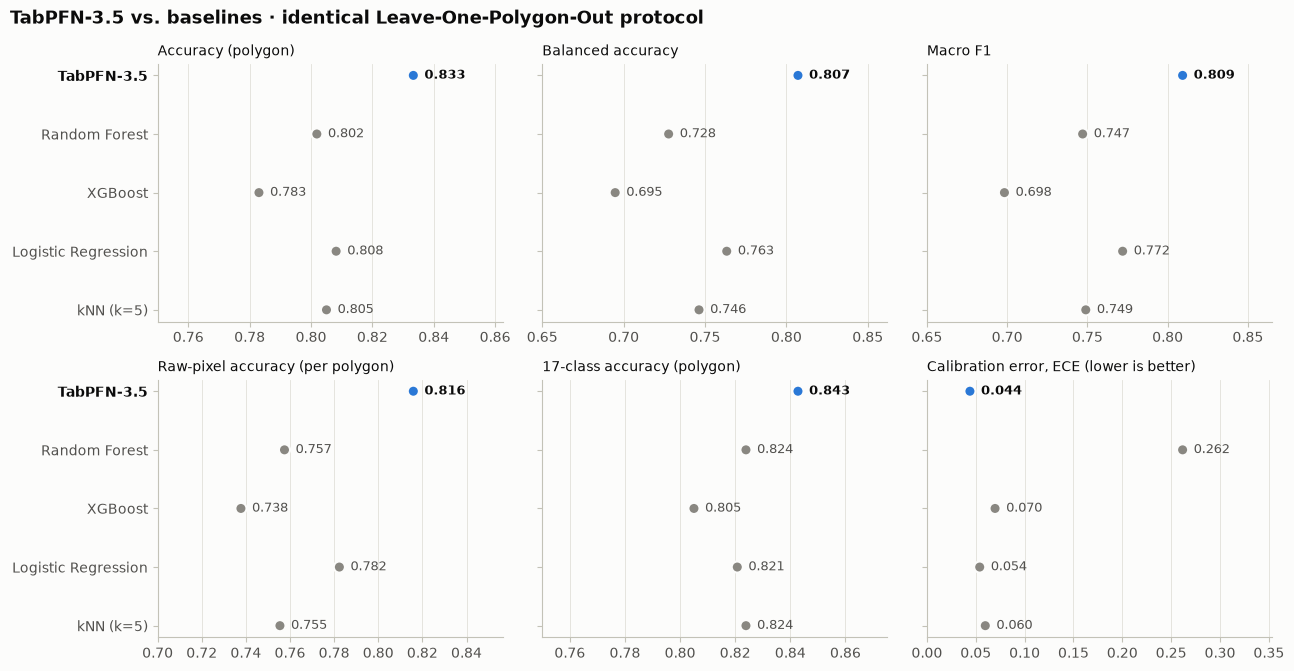

Saved model comparison figure: /u/mayeh/Gh_LC/outputs_tabpfn35_polygon/model_comparison.png
Saved LOO probabilities: /u/mayeh/Gh_LC/outputs_tabpfn35_polygon/loo_probabilities.npz


In [9]:
# ==========================================
# 8. Baseline Classifiers under the Identical LOO Protocol
# ==========================================
# Every baseline is scored by the same lc_eval.run_loo call as TabPFN-3.5: the
# same 318 folds, the same polygon-mean training rows and the same raw-pixel
# scoring. Baselines use fixed, standard configurations and TabPFN-3.5 uses its
# default checkpoint settings; no model is hyperparameter-tuned.
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

BASELINES = {
    'Random Forest': lambda: RandomForestClassifier(
        n_estimators=500, n_jobs=-1, random_state=RANDOM_STATE),
    'XGBoost': lambda: lc_eval.LabelEncodedXGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
        tree_method='hist', n_jobs=-1, random_state=RANDOM_STATE),
    'Logistic Regression': lambda: make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=5000)),
    'kNN (k=5)': lambda: KNeighborsClassifier(n_neighbors=5, weights='distance'),
}

loo_results = {'TabPFN-3.5': tabpfn_loo}
for name, make_model in BASELINES.items():
    loo_results[name] = lc_eval.run_loo(
        make_model=make_model,
        X=X_poly,
        y=y_poly,
        polygon_ids=polygon_ids,
        raw_pixels_by_polygon=raw_pixels_by_polygon,
        classes=classes,
        model_name=name,
        code_to_name=code_to_name,
        progress_every=106,
    )

comparison_df = pd.DataFrame(
    [lc_eval.summarize_loo(r, reclass_lut, n_bins=RELIABILITY_BINS) for r in loo_results.values()]
)
comparison_path = os.path.join(OUTPUT_DIR, 'model_comparison.csv')
comparison_df.to_csv(comparison_path, index=False)

headline_cols = [
    'model', 'accuracy_polygon_mean', 'balanced_accuracy_polygon_mean', 'macro_f1',
    'raw_pixel_accuracy_micro', 'raw_pixel_accuracy_macro', 'raw_pixel_accuracy_class_balanced',
    'accuracy_17class_polygon_mean', 'log_loss', 'brier_score', 'ece_polygon_mean',
    'ece_raw_pixel_polygon_weighted', 'loo_seconds',
]
display(comparison_df[headline_cols].round(4))
print(f'Saved model comparison: {comparison_path}')

fig = lc_eval.plot_model_comparison(comparison_df, highlight='TabPFN-3.5')
comparison_png_path = os.path.join(OUTPUT_DIR, 'model_comparison.png')
fig.savefig(comparison_png_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved model comparison figure: {comparison_png_path}')

# Out-of-sample probabilities and pixel-level predictions of every model.
model_keys = {
    'TabPFN-3.5': 'tabpfn_3_5', 'Random Forest': 'random_forest', 'XGBoost': 'xgboost',
    'Logistic Regression': 'logistic_regression', 'kNN (k=5)': 'knn_k5',
}
npz_arrays = {
    'classes': classes,
    'polygon_ids': polygon_ids.to_numpy().astype(str),
    'true_code': y_poly.to_numpy(),
    'model_names': np.array(list(model_keys)),
    'model_keys': np.array(list(model_keys.values())),
    'pixel_polygon_index': tabpfn_loo.pixel_polygon_index,
}
for name, r in loo_results.items():
    key = model_keys[name]
    npz_arrays[f'{key}__proba'] = r.proba
    npz_arrays[f'{key}__pixel_pred'] = r.pixel_pred
    npz_arrays[f'{key}__pixel_conf'] = r.pixel_conf
    npz_arrays[f'{key}__pixel_correct'] = r.pixel_correct
probabilities_path = os.path.join(OUTPUT_DIR, 'loo_probabilities.npz')
np.savez_compressed(probabilities_path, **npz_arrays)
print(f'Saved LOO probabilities: {probabilities_path}')

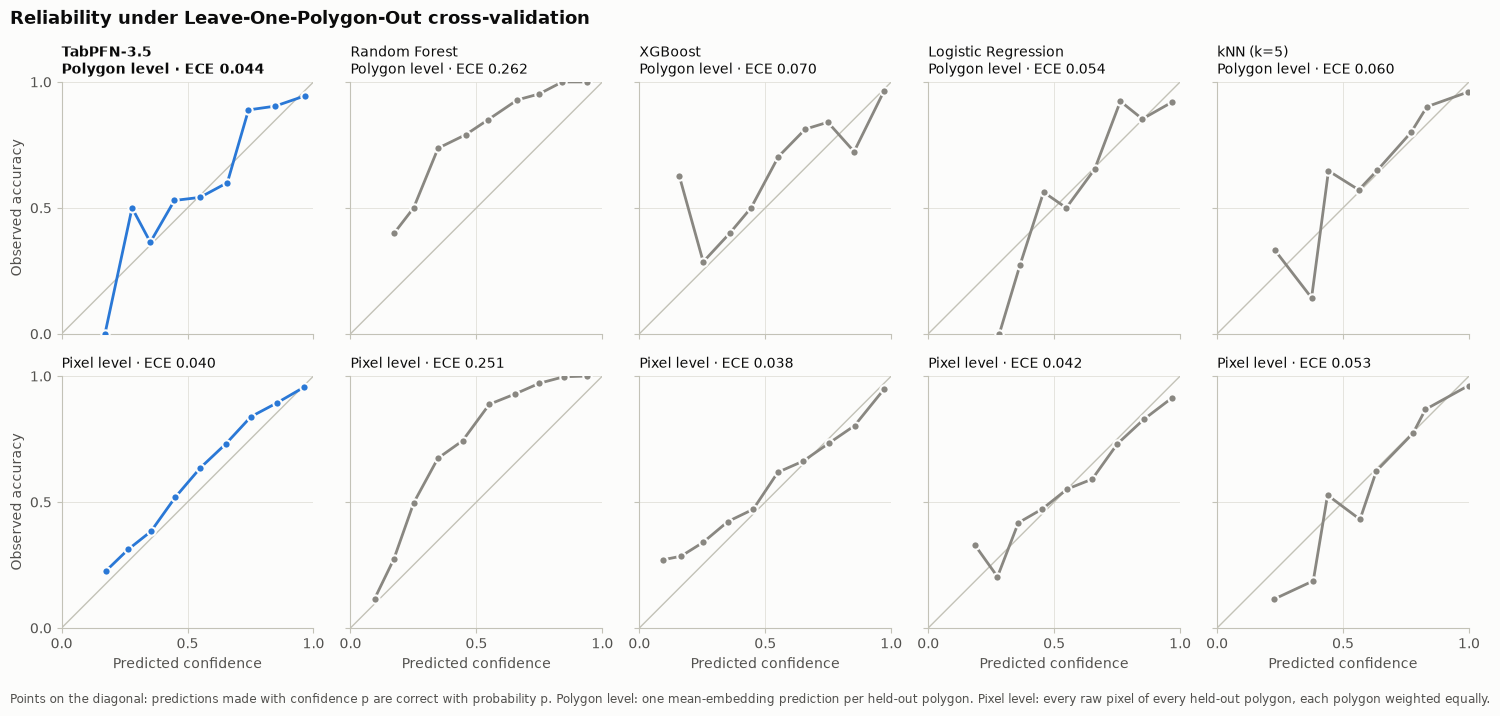

Saved reliability diagrams: /u/mayeh/Gh_LC/outputs_tabpfn35_polygon/reliability_diagram.png
Saved calibration bins: /u/mayeh/Gh_LC/outputs_tabpfn35_polygon/calibration_bins.csv
Saved calibration summary: /u/mayeh/Gh_LC/outputs_tabpfn35_polygon/calibration_summary.json


,"ECE, polygon_mean","ECE, raw_pixel_polygon_weighted","ECE, raw_pixel_micro"
TabPFN-3.5,0.0440,0.0397,0.0647
Random Forest,0.2617,0.2512,0.2614
XGBoost,0.0697,0.0383,0.0301
Logistic Regression,0.0540,0.0423,0.0432
kNN (k=5),0.0597,0.0529,0.1273


TabPFN-3.5, held-out pixels (each polygon weighted equally): confidence < 0.6 -> 51.7% correct (22.2% of pixels); confidence >= 0.6 -> 90.1% correct.


In [10]:
# ==========================================
# 9. Calibration of Predicted Probabilities
# ==========================================
# Reliability diagrams bin predictions by top-class probability and compare each
# bin's mean confidence with its observed accuracy; points on the diagonal mean
# that a prediction made with confidence p is correct with probability p.
#   polygon level: one mean-embedding prediction per held-out polygon
#   pixel level:   every raw pixel of every held-out polygon, each polygon
#                  weighted equally - the setting of the wall-to-wall map
import json

fig = lc_eval.plot_reliability_diagrams(loo_results, n_bins=RELIABILITY_BINS, highlight='TabPFN-3.5')
reliability_path = os.path.join(OUTPUT_DIR, 'reliability_diagram.png')
fig.savefig(reliability_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved reliability diagrams: {reliability_path}')

calibration_levels = {
    'polygon_mean': 'one mean-embedding prediction per held-out polygon',
    'raw_pixel_polygon_weighted': 'every raw pixel of every held-out polygon, each polygon weighted equally',
    'raw_pixel_micro': 'every raw pixel of every held-out polygon, each pixel weighted equally',
}
bin_tables = []
calibration_models = {}
for name, r in loo_results.items():
    level_inputs = {
        'polygon_mean': (r.records['confidence'].to_numpy(), r.records['correct'].to_numpy(), None),
        'raw_pixel_polygon_weighted': (r.pixel_conf, r.pixel_correct, lc_eval.pixel_polygon_weights(r)),
        'raw_pixel_micro': (r.pixel_conf, r.pixel_correct, None),
    }
    calibration_models[name] = {}
    for level, (conf, correct, weights) in level_inputs.items():
        table, ece = lc_eval.reliability_table(conf, correct, weights=weights, n_bins=RELIABILITY_BINS)
        bin_tables.append(table.assign(model=name, level=level))
        calibration_models[name][level] = {
            'ece': ece,
            **lc_eval.confidence_threshold_summary(conf, correct, LOW_CONFIDENCE_THRESHOLD, weights=weights),
        }

calibration_bins_df = pd.concat(bin_tables, ignore_index=True)[
    ['model', 'level', 'bin_low', 'bin_high', 'weight_share', 'mean_confidence', 'accuracy']
]
calibration_bins_path = os.path.join(OUTPUT_DIR, 'calibration_bins.csv')
calibration_bins_df.to_csv(calibration_bins_path, index=False)

calibration_summary = {
    'low_confidence_threshold': LOW_CONFIDENCE_THRESHOLD,
    'n_bins': RELIABILITY_BINS,
    'levels': calibration_levels,
    'models': calibration_models,
}
calibration_json_path = os.path.join(OUTPUT_DIR, 'calibration_summary.json')
with open(calibration_json_path, 'w') as f:
    json.dump(calibration_summary, f, indent=4)
print(f'Saved calibration bins: {calibration_bins_path}')
print(f'Saved calibration summary: {calibration_json_path}')

ece_table = pd.DataFrame({
    name: {f'ECE, {level}': values[level]['ece'] for level in calibration_levels}
    for name, values in calibration_models.items()
}).T
display(ece_table.round(4))

t = calibration_models['TabPFN-3.5']['raw_pixel_polygon_weighted']
print(f'TabPFN-3.5, held-out pixels (each polygon weighted equally): '
      f'confidence < {LOW_CONFIDENCE_THRESHOLD} -> {t["accuracy_below"]:.1%} correct '
      f'({t["share_below"]:.1%} of pixels); confidence >= {LOW_CONFIDENCE_THRESHOLD} -> '
      f'{t["accuracy_at_or_above"]:.1%} correct.')

In [11]:
# ==========================================
# 10. Fit & Export the Final Deployable Model (all 318 polygons)
# ==========================================
import time
import joblib

print(f'Fitting final TabPFN-3.5 model on all {len(X_poly)} polygons...')
t0 = time.time()
tabpfn35_classifier.fit(X_poly, y_poly)
fit_duration = time.time() - t0
print(f'Final fit completed in {fit_duration:.2f}s.')

model_path = os.path.join(OUTPUT_DIR, 'tabpfn35_polygon_model.joblib')
joblib.dump(tabpfn35_classifier, model_path)
print(f'Saved final deployable model: {model_path}')

baseline_summary_cols = [
    'accuracy_polygon_mean', 'balanced_accuracy_polygon_mean', 'macro_f1',
    'raw_pixel_accuracy_micro', 'raw_pixel_accuracy_macro', 'raw_pixel_accuracy_class_balanced',
    'accuracy_17class_polygon_mean', 'log_loss', 'brier_score', 'ece_polygon_mean',
    'ece_raw_pixel_polygon_weighted',
]
metrics_summary = {
    'model': 'TabPFNClassifier (TabPFN-3.5 standard checkpoint, polygon level)',
    'framework': 'PyTorch / Prior Labs tabpfn>=9.0.0',
    'n_classes': int(len(classes)),
    'n_final_legend_classes': int(len(final_code_to_name)),
    'n_raw_pixel_rows': int(df.shape[0]),
    'n_independent_polygons': int(len(X_poly)),
    'evaluation': ('Leave-One-Polygon-Out cross-validation: each polygon held out exactly once; '
                   'its mean embedding and all of its raw pixels scored by the same fold model'),
    **{k: v for k, v in tabpfn_summary.items() if k != 'model'},
    'loo_cv_total_time_seconds': float(tabpfn_loo.seconds),
    'final_fit_time_seconds': float(fit_duration),
    'class_mapping': {int(k): str(v) for k, v in code_to_name.items()},
    'final_legend': {int(k): str(v) for k, v in final_code_to_name.items()},
    'polygons_per_class': {int(k): int(v) for k, v in poly_counts.items()},
    'classes_with_fewer_than_10_polygons': sorted(int(c) for c in poly_counts.index if poly_counts[c] < 10),
    'held_out_pixel_share_by_class': {
        str(row['name']): float(row['share_of_held_out_pixels']) for _, row in composition_df.iterrows()
    },
    'baseline_comparison': comparison_df.set_index('model')[baseline_summary_cols].to_dict(orient='index'),
    'note': (
        'accuracy_polygon_mean scores one mean-embedding row per held-out polygon. raw_pixel_accuracy_* '
        'score every raw pixel of each held-out polygon: micro weights pixels equally, macro weights '
        'polygons equally, class_balanced weights classes equally. *_17class_* metrics use the final '
        '17-class legend (new_class.xlsx). Per-class Wilson 95% CIs: polygon_class_summary.csv. '
        'Baselines: model_comparison.csv. Calibration: calibration_summary.json.'
    ),
}
metrics_json_path = os.path.join(OUTPUT_DIR, 'polygon_metrics_summary.json')
with open(metrics_json_path, 'w') as f:
    json.dump(metrics_summary, f, indent=4, default=lambda o: o.item() if hasattr(o, 'item') else str(o))
print(f'Saved metrics summary: {metrics_json_path}')

Fitting final TabPFN-3.5 model on all 318 polygons...
Final fit completed in 1.61s.
Saved final deployable model: /u/mayeh/Gh_LC/outputs_tabpfn35_polygon/tabpfn35_polygon_model.joblib
Saved metrics summary: /u/mayeh/Gh_LC/outputs_tabpfn35_polygon/polygon_metrics_summary.json


## Notes

- **Classes with few polygons.** Classes backed by fewer than 10 polygons are flagged (`caution_small_n`) and
  their LOO accuracies carry Wilson 95% confidence intervals in `polygon_class_summary.csv`. Additional field
  polygons for these classes are the most direct way to strengthen both the map and its evaluation.
- **Polygon means and individual pixels.** The model is fit on polygon-mean embeddings and applied to
  individual pixels. Raw-pixel scoring in every LOO fold measures performance in that setting, reported
  three ways: micro (every pixel equal, shaped by large polygons - see `held_out_pixel_composition.csv`),
  macro (every polygon equal) and class-balanced (every class equal).
- **Final legend.** The 17-class metrics score the same LOO predictions after merging classes into the legend
  of the published map (e.g. cocoa, cashew, rubber, palm and mango into Tree Crop Plantation).
- **Baselines.** All five models share one LOO runner and receive identical inputs; none is tuned.
- **Calibration.** `calibration_summary.json` records, for every model, the ECE at each level and the accuracy
  above and below the low-confidence threshold reported on the prediction notebook's confidence map.
- **Next step.** `Predict_TabPFN35_PolygonLevel.ipynb` loads `tabpfn35_polygon_model.joblib`,
  `polygon_metrics_summary.json` and `calibration_summary.json` and classifies every embedding tile in `Images/`.